In [36]:
query = """
SELECT
    Segment,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
FROM retail_sales
GROUP BY Segment
ORDER BY Total_Profit DESC;
"""

pd.read_sql(query, conn)

,Segment,Total_Sales,Total_Profit,Profit_Margin
0,Consumer,1170659.79,136371.45,11.65
1,Corporate,715806.13,94249.64,13.17
2,Home Office,440068.43,61675.73,14.02


In [35]:
query = """
SELECT
    Discount,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(*) AS Transactions,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
FROM retail_sales
WHERE Category = 'Furniture'
GROUP BY Discount
ORDER BY Discount;
"""

pd.read_sql(query, conn)

,Discount,Total_Sales,Total_Profit,Transactions,Profit_Margin
0,0.00,260155.06,59476.99,880,22.86
1,0.10,47217.39,7181.80,78,15.21
2,0.15,27558.52,1418.99,52,5.15
3,0.20,223393.35,6608.50,636,2.96
4,0.30,100191.18,-10786.83,224,-10.77
5,0.32,14493.46,-2391.14,27,-16.50
6,0.40,45614.41,-16187.40,75,-35.49
7,0.45,5484.97,-2493.11,11,-45.45
8,0.50,20983.47,-12871.20,54,-61.34
9,0.60,7051.98,-6134.07,147,-86.98


In [34]:
query = """
SELECT
    Category,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
FROM retail_sales
GROUP BY Category
ORDER BY Total_Profit DESC;
"""

pd.read_sql(query, conn)

,Category,Total_Sales,Total_Profit,Profit_Margin
0,Technology,839893.28,146543.38,17.45
1,Office Supplies,731893.31,126023.44,17.22
2,Furniture,754747.76,19730.00,2.61


In [33]:
query = """
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
FROM retail_sales
GROUP BY Region
ORDER BY Total_Profit DESC;
"""

pd.read_sql(query, conn)

,Region,Total_Sales,Total_Profit,Profit_Margin
0,West,739813.61,110798.82,14.98
1,East,691828.17,94883.26,13.71
2,South,391721.91,46749.43,11.93
3,Central,503170.67,39865.31,7.92


In [32]:
query = """
SELECT
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND((SUM(Profit) / SUM(Sales)) * 100, 2) AS Profit_Margin
FROM retail_sales;
"""

pd.read_sql(query, conn)

,Total_Sales,Total_Profit,Profit_Margin
0,2326534.35,292296.81,12.56


In [30]:
pd.read_sql(
    "SELECT * FROM retail_sales LIMIT 5",
    conn
)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin
0,1,US-2023-103800,2023-01-03 00:00:00,2023-01-07 00:00:00,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,33.75
1,2,US-2023-112326,2023-01-04 00:00:00,2023-01-08 00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,-155.00
2,3,US-2023-112326,2023-01-04 00:00:00,2023-01-08 00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,36.25
3,4,US-2023-112326,2023-01-04 00:00:00,2023-01-08 00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,-23.75
4,5,US-2023-141817,2023-01-05 00:00:00,2023-01-12 00:00:00,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,25.00


In [29]:
import sqlite3

conn = sqlite3.connect("../sql/retail_sales.db")

df.to_sql(
    "retail_sales",
    conn,
    if_exists="replace",
    index=False
)

print("SQLite database created successfully!")

SQLite database created successfully!


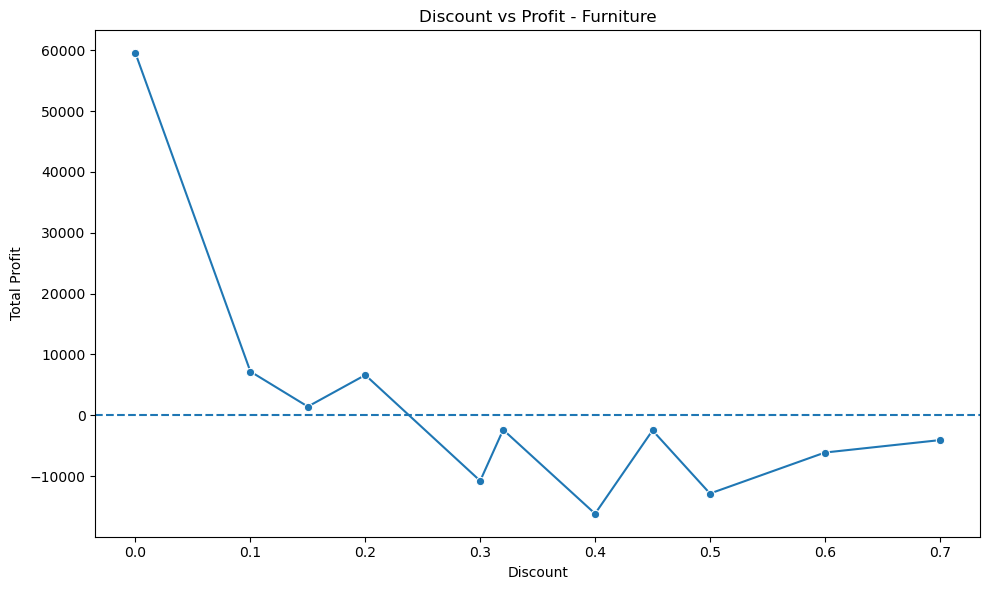

In [28]:
furniture_data = df[df["Category"] == "Furniture"]

discount_profit = furniture_data.groupby("Discount").agg(
    Total_Profit=("Profit", "sum")
).reset_index()

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=discount_profit,
    x="Discount",
    y="Total_Profit",
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Discount vs Profit - Furniture")
plt.xlabel("Discount")
plt.ylabel("Total Profit")

plt.tight_layout()

plt.savefig(
    "../visualizations/discount_vs_profit_furniture.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

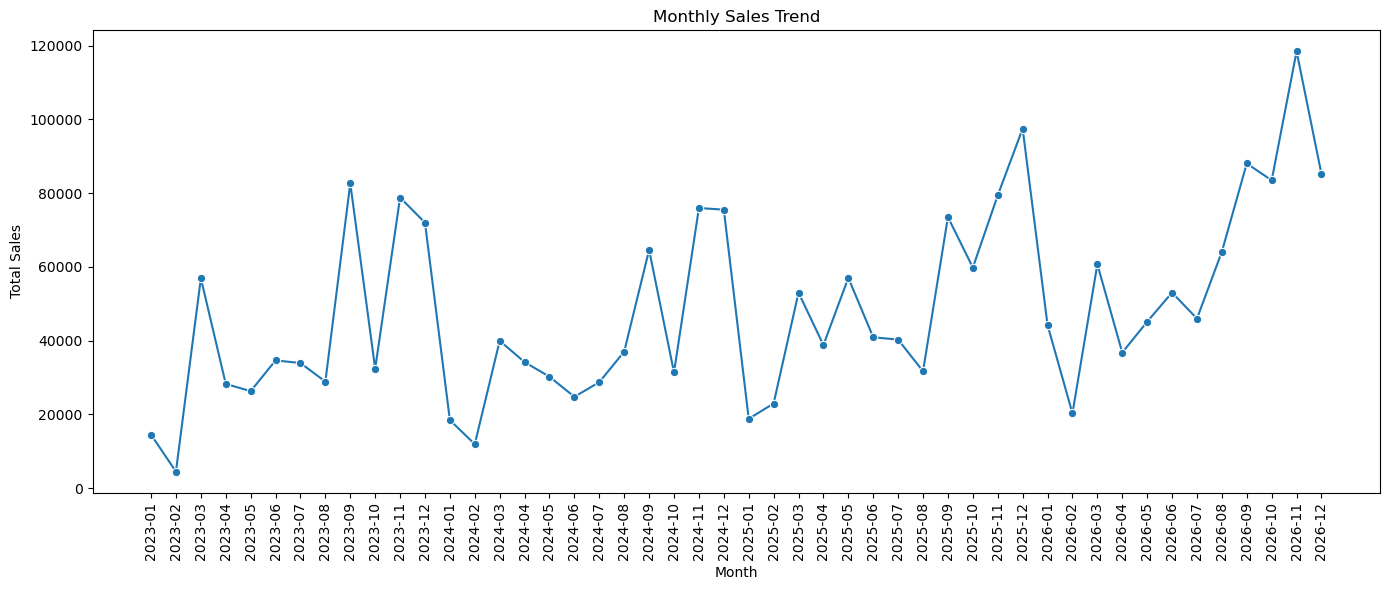

In [27]:
monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum().reset_index()

monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x="Order Date",
    y="Sales",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../visualizations/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

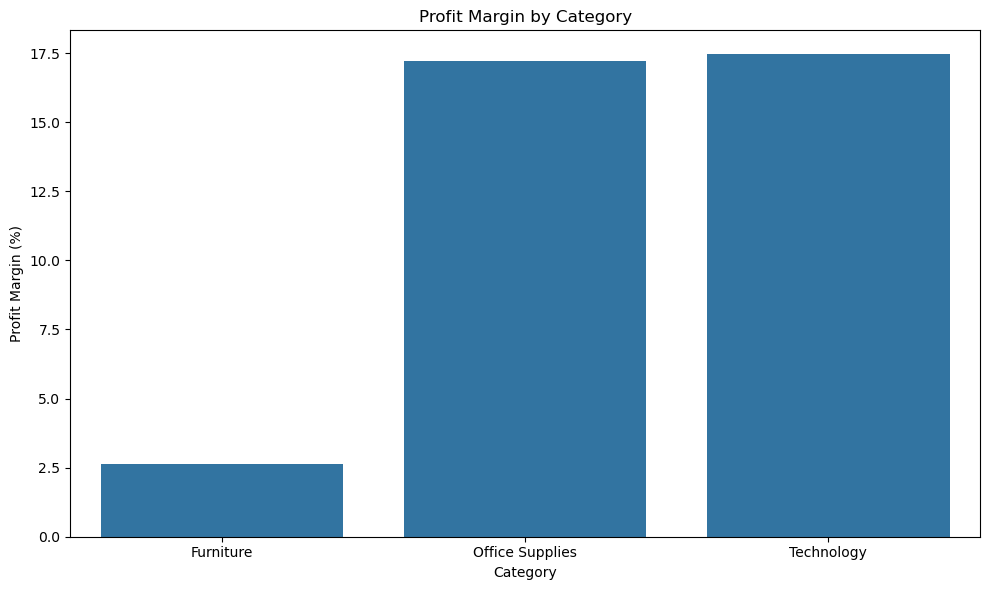

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_analysis,
    x="Category",
    y="Profit_Margin"
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()

plt.savefig("../visualizations/category_profit_margin.png", dpi=300, bbox_inches="tight")

plt.show()

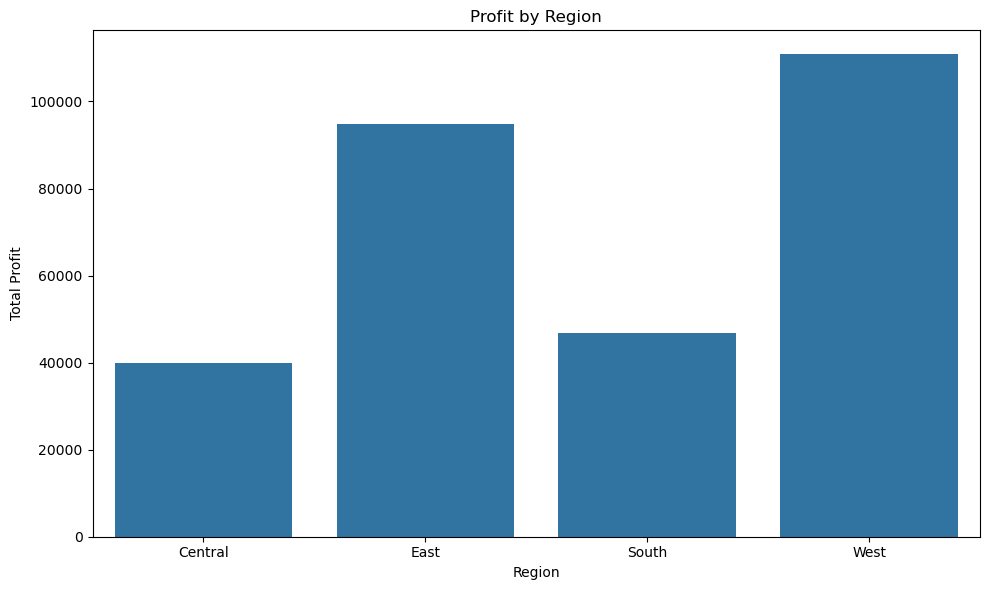

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_analysis,
    x="Region",
    y="Total_Profit"
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.tight_layout()

plt.savefig("../visualizations/profit_by_region.png", dpi=300, bbox_inches="tight")

plt.show()

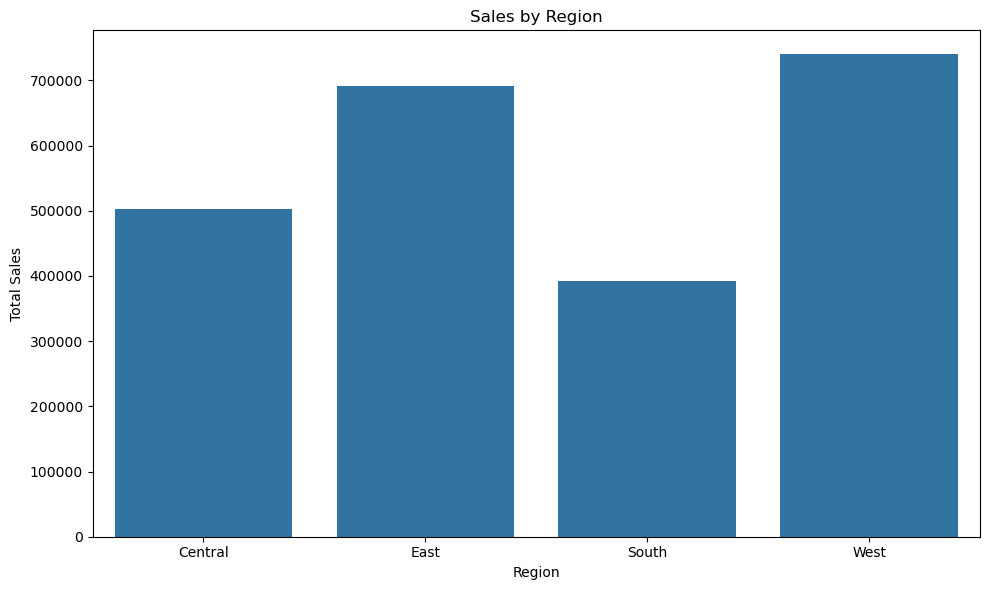

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_analysis,
    x="Region",
    y="Total_Sales"
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../visualizations/sales_by_region.png", dpi=300, bbox_inches="tight")

plt.show()

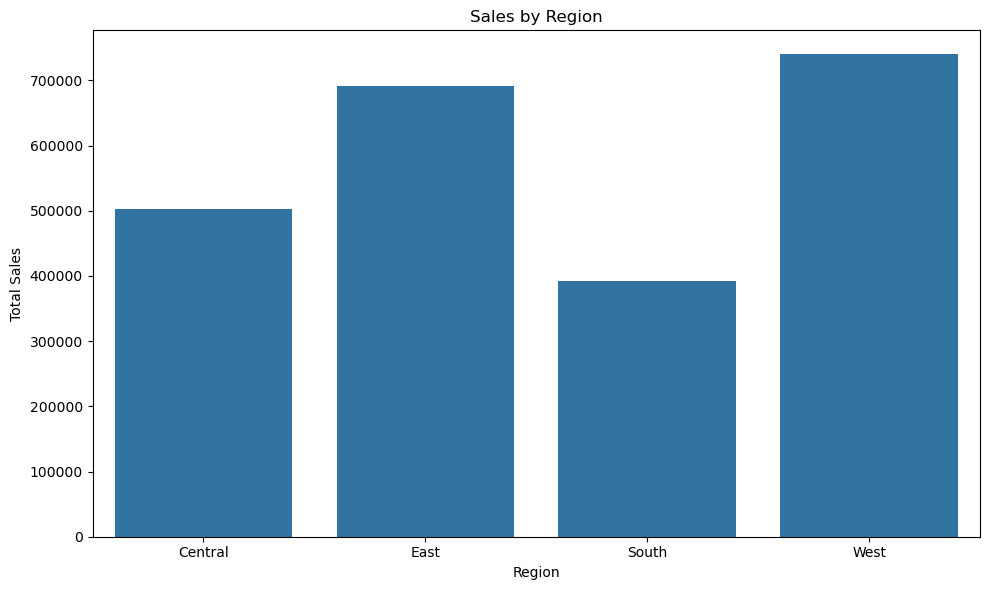

<Figure size 640x480 with 0 Axes>

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_analysis,
    x="Region",
    y="Total_Sales"
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig("../visualizations/sales_by_region.png", dpi=300, bbox_inches="tight")

In [20]:
segment_analysis = df.groupby("Segment").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
).reset_index()

segment_analysis["Profit_Margin"] = (
    segment_analysis["Total_Profit"] /
    segment_analysis["Total_Sales"]
) * 100

segment_analysis.sort_values("Total_Profit", ascending=False)

,Segment,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin
0,Consumer,1.170660e+06,136371.4463,19844,11.649110
1,Corporate,7.158061e+05,94249.6400,11898,13.166923
2,Home Office,4.400684e+05,61675.7283,6912,14.015031


In [21]:
segment_analysis = df.groupby("Segment").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
).reset_index()

segment_analysis["Profit_Margin"] = (
    segment_analysis["Total_Profit"] /
    segment_analysis["Total_Sales"]
) * 100

segment_analysis.sort_values("Total_Profit", ascending=False)

,Segment,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin
0,Consumer,1.170660e+06,136371.4463,19844,11.649110
1,Corporate,7.158061e+05,94249.6400,11898,13.166923
2,Home Office,4.400684e+05,61675.7283,6912,14.015031


In [19]:
furniture_discount = df[df["Category"] == "Furniture"].groupby("Discount").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Transactions=("Order ID", "count")
).reset_index()

furniture_discount["Profit_Margin"] = (
    furniture_discount["Total_Profit"] /
    furniture_discount["Total_Sales"]
) * 100

furniture_discount.sort_values("Discount")

,Discount,Total_Sales,Total_Profit,Transactions,Profit_Margin
0,0.00,260155.0600,59476.9872,880,22.862130
1,0.10,47217.3930,7181.8049,78,15.210083
2,0.15,27558.5215,1418.9915,52,5.149012
3,0.20,223393.3480,6608.4977,636,2.958234
4,0.30,100191.1800,-10786.8269,224,-10.766244
5,0.32,14493.4588,-2391.1377,27,-16.498047
6,0.40,45614.4060,-16187.3968,75,-35.487466
7,0.45,5484.9740,-2493.1111,11,-45.453472
8,0.50,20983.4700,-12871.1990,54,-61.339707
9,0.60,7051.9800,-6134.0712,147,-86.983673


In [18]:
category_analysis = df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
).reset_index()

category_analysis["Profit_Margin"] = (
    category_analysis["Total_Profit"] /
    category_analysis["Total_Sales"]
) * 100

category_analysis.sort_values("Total_Profit", ascending=False)

,Category,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin
2,Technology,839893.2790,146543.3756,7017,17.447857
1,Office Supplies,731893.3140,126023.4434,23268,17.218827
0,Furniture,754747.7613,19729.9956,8369,2.614118


In [17]:
region_analysis.sort_values(
    "Total_Profit",
    ascending=False
)

,Region,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin
3,West,739813.6085,110798.8170,12466,14.976585
1,East,691828.1680,94883.2603,11159,13.714859
2,South,391721.9050,46749.4303,6209,11.934342
0,Central,503170.6728,39865.3070,8820,7.922820


In [16]:
region_analysis = df.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
).reset_index()

region_analysis["Profit_Margin"] = (
    region_analysis["Total_Profit"] /
    region_analysis["Total_Sales"]
) * 100

region_analysis

,Region,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin
0,Central,503170.6728,39865.3070,8820,7.922820
1,East,691828.1680,94883.2603,11159,13.714859
2,South,391721.9050,46749.4303,6209,11.934342
3,West,739813.6085,110798.8170,12466,14.976585


In [15]:
df[["Sales", "Profit", "Profit Margin"]].head()

,Sales,Profit,Profit Margin
0,16.448,5.5512,33.75
1,3.540,-5.4870,-155.00
2,11.784,4.2717,36.25
3,272.736,-64.7748,-23.75
4,19.536,4.8840,25.00


In [14]:
df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100

In [12]:
print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))
print("Total Quantity Sold:", df["Quantity"].sum())
print("Average Discount:", round(df["Discount"].mean() * 100, 2), "%")
print("Total Transactions:", len(df))
print("Unique Orders:", df["Order ID"].nunique())

Total Sales: 2326534.35
Total Profit: 292296.81
Total Quantity Sold: 38654
Average Discount: 15.54 %
Total Transactions: 10194
Unique Orders: 5111


In [11]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002942720,2025-05-03 10:52:45.626839296,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


In [10]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [5]:
df.shape

(10194, 21)

In [7]:
import pandas as pd

df = pd.read_excel("../data/sample_-_superstore.xls")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840
